In [10]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
study = optuna.load_study(
    storage=r"sqlite:///surf.sqlite3",
    study_name="resnet_50_128img_pre_infer_XYZ_detail",
)

In [12]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
df.describe()

,number,value,datetime_start,datetime_complete,duration,params_x,params_y,params_z,user_attrs_attempts,user_attrs_failed
count,2751.00000,2751.000000,2751,2751,2751,2751.000000,2751.000000,2751.000000,2751.000000,2751.000000
mean,1375.00000,0.757701,2026-04-19 10:50:17.002914,2026-04-19 10:50:40.771085,0 days 00:00:23.768170,120.074009,154.352417,0.243948,2.002545,0.283170
min,0.00000,0.606250,2026-04-18 19:24:16.838776,2026-04-18 19:24:33.585384,0 days 00:00:14.392397,113.000000,148.000000,0.000000,2.000000,0.000000
25%,687.50000,0.757812,2026-04-18 23:48:22.960178,2026-04-18 23:48:39.472185,0 days 00:00:16.363361,116.600000,151.000000,0.130000,2.000000,0.000000
50%,1375.00000,0.757812,2026-04-19 14:25:03.605193,2026-04-19 14:25:20.083309,0 days 00:00:16.737570,120.000000,154.700000,0.240000,2.000000,0.000000
75%,2062.50000,0.757812,2026-04-19 19:09:06.232517,2026-04-19 19:09:23.044470,0 days 00:00:17.202157,123.400000,157.600000,0.360000,2.000000,0.000000
max,2750.00000,0.757812,2026-04-19 23:43:51.687273,2026-04-19 23:44:08.290782,0 days 00:01:54.478784,127.000000,160.000000,0.500000,5.000000,2.000000
std,794.28962,0.004086,NaN,NaN,0 days 00:00:18.221429,4.094529,3.656347,0.137975,0.083082,0.677002


In [13]:
df = df.explode("user_attrs_top-1")

df = df.reset_index(drop=True)

In [14]:
df = df[["params_x", "params_y", "params_z", "user_attrs_top-1"]]
df.to_csv("data.csv", index=False)

In [15]:
df_unchanged = df[df["user_attrs_top-1"] == 0.7578125]
df_failed = df[df["user_attrs_top-1"] == -1]
df_one = df[(df["user_attrs_top-1"] != 0.7578125) & (df["user_attrs_top-1"] != -1)]
df_success = df[(df["user_attrs_top-1"] < 0.5) & (df["user_attrs_top-1"] != -1)]

In [16]:
df.head()

,params_x,params_y,params_z,user_attrs_top-1
0,125.1,148.7,0.17,0.757812
1,125.1,148.7,0.17,0.757812
2,115.5,159.7,0.24,0.757812
3,115.5,159.7,0.24,0.757812
4,121.3,155.3,0.32,0.757812


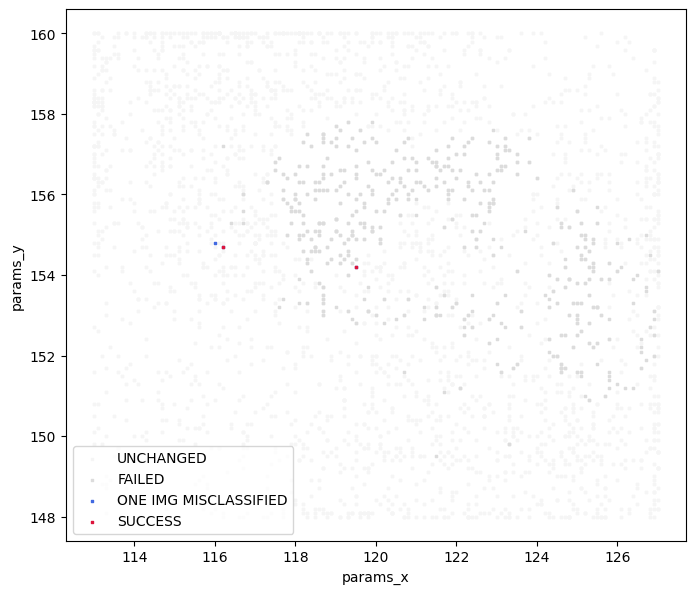

In [17]:
SCALE = 8
MARKER = 1

fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=MARKER,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=MARKER,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=MARKER,
    marker="s",
)

ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=MARKER,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("2d.svg")